# 3. Lick Metrics — does anticipatory licking narrow onto the reward zone?

Per session, from `{rec}_lickproc.h5` (notebook 2):

1. **Classify** licks — carryover / approach / consummatory
2. **Lick-rate-vs-VR-position** curve (occupancy-normalised) — the core readout
3. **Reward-aligned PSTH** — the temporal view
4. **Per-trial first-lick position**
5. **Within-session** early vs late trials
6. **Speed control** — is "narrowing" just deceleration near the reward?
7. **Metrics row** -> `{rec}_lickmetrics.{csv,h5}` for notebook 4

The theory: early = licking scattered anywhere in the corridor; with learning
the anticipatory licking concentrates in the last stretch before the reward
zone (spatially **and** temporally).

In [1]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

MODULE_DIR = r"C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\10.LickingBehavior"
sys.path.insert(0, MODULE_DIR)
from lick_io import read_vrlog
from lick_sync import frame_to_vr, vr_to_frame, load_sync_model
from lick_metrics import (classify_licks, lick_rate_vs_position, speed_vs_position,
                          reward_psth, first_approach_lick, session_metrics)

# ---------------- CONFIG ----------------
RECORDING_FOLDER = r"F:\dlc\test"
FPS       = 30.0
POS_BINW  = 15.0        # position bin width (au)
ANTIC_SPAN   = 60.0     # "reward-zone" = last this-many au before the reward
NEUTRAL_ZONE = (60.0, None)   # (lo, hi); hi=None -> reward_zone - NEUTRAL_PAD
NEUTRAL_PAD  = 120.0
PSTH_WINDOW  = (-4.0, 3.0)
PSTH_BINW    = 0.1

plt.rcParams["figure.dpi"] = 110

## Load notebook-2 output

In [2]:
LICKPROC_H5 = glob.glob(os.path.join(RECORDING_FOLDER, "*_lickproc.h5"))[0]
with h5py.File(LICKPROC_H5, "r") as f:
    assert "licks" in f, "run 2.LickDetection.ipynb first"
    trial_df = pd.DataFrame({k: f["trials"][k][:] for k in f["trials"]})
    licks_df = pd.DataFrame({k: (f["licks"][k][:].astype(str) if f["licks"][k].dtype.kind == "S"
                                 else f["licks"][k][:]) for k in f["licks"]})
    bout_start = f["bouts/start_frame"][:]
    RECORDING      = f.attrs["recording"]
    REWARD_ZONE_AU = float(f.attrs["reward_zone_au"])
    VRLOG_PATH     = f.attrs["vrlog_path"]

model = load_sync_model(LICKPROC_H5)
vr = read_vrlog(VRLOG_PATH)
trial_df["trial"] = trial_df["trial"].astype(int)
licks_df["trial"] = licks_df["trial"].astype(int)
licks_df["bout_id"] = licks_df["bout_id"].astype(int)

print(f"{RECORDING}   {len(trial_df)} trials   {len(licks_df)} licks   reward zone ~ {REWARD_ZONE_AU:.0f} au")

260618_JSY083_B1   98 trials   1572 licks   reward zone ~ 392 au


## 1. Classify licks

In [3]:
licks_df = classify_licks(licks_df, trial_df, bout_start)
print(licks_df.category.value_counts())
print()
print("  carryover    = still drinking from the previous reward (bout began pre-teleport)")
print("  approach     = has a VR position (animal running the corridor)")
print("  consummatory = no position (at the reward zone / in the ITI)")

category
consummatory    1068
approach         438
carryover         66
Name: count, dtype: int64

  carryover    = still drinking from the previous reward (bout began pre-teleport)
  approach     = has a VR position (animal running the corridor)
  consummatory = no position (at the reward zone / in the ITI)


## 2. Lick-rate vs. VR position  (occupancy-normalised)

Licks per position bin ÷ time spent in that bin. Slowing near the reward would
otherwise inflate the raw count there.

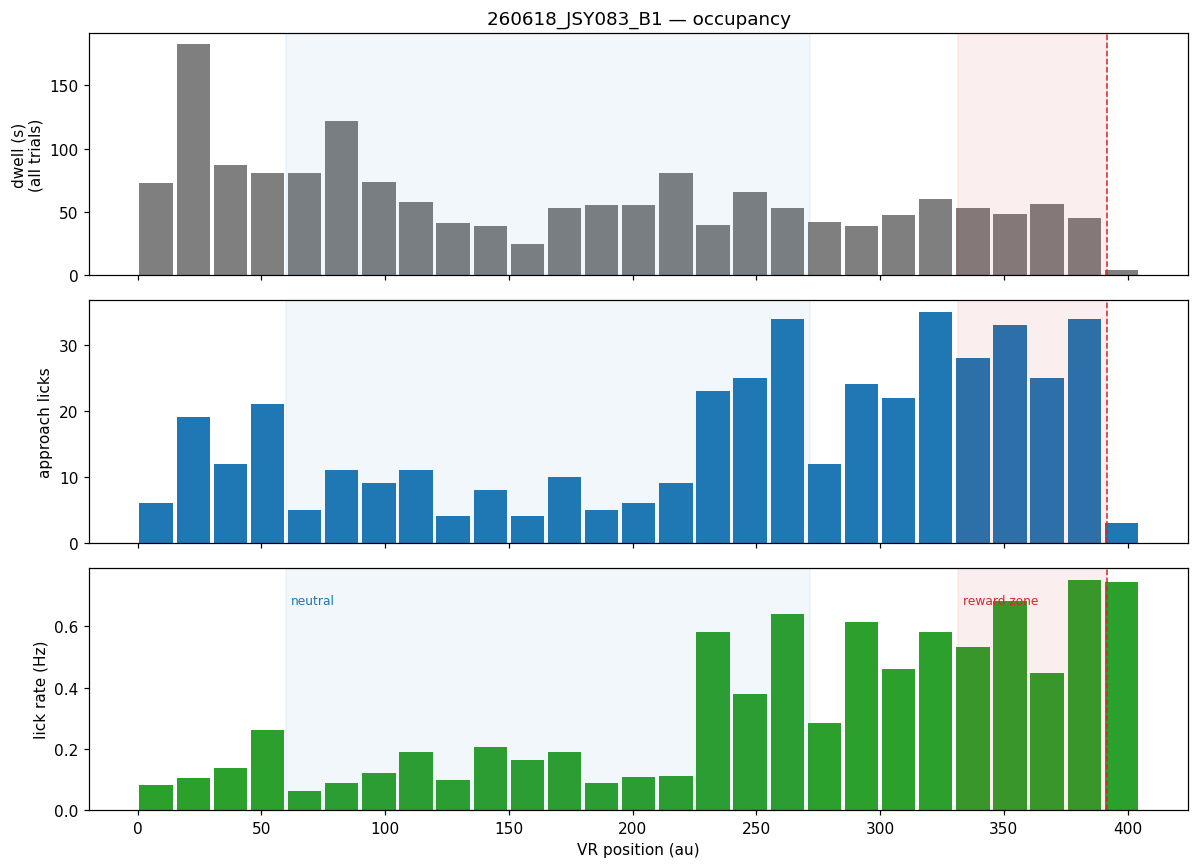

In [4]:
curve = lick_rate_vs_position(licks_df, vr, trial_df, binw=POS_BINW)
speed = speed_vs_position(vr, trial_df, binw=POS_BINW)

fig, axs = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axs[0].bar(curve.bin_center, curve.dwell_s, POS_BINW * 0.9, color="tab:gray")
axs[0].set_ylabel("dwell (s)\n(all trials)"); axs[0].set_title(f"{RECORDING} — occupancy")

axs[1].bar(curve.bin_center, curve.n_licks, POS_BINW * 0.9, color="tab:blue")
axs[1].set_ylabel("approach licks")

axs[2].bar(curve.bin_center, curve.rate_hz, POS_BINW * 0.9, color="tab:green")
axs[2].set_ylabel("lick rate (Hz)"); axs[2].set_xlabel("VR position (au)")

rz_lo = REWARD_ZONE_AU - ANTIC_SPAN
neu_hi = REWARD_ZONE_AU - NEUTRAL_PAD
for ax in axs:
    ax.axvline(REWARD_ZONE_AU, color="tab:red", ls="--", lw=1)
    ax.axvspan(rz_lo, REWARD_ZONE_AU, color="tab:red", alpha=0.08)
    ax.axvspan(NEUTRAL_ZONE[0], neu_hi, color="tab:blue", alpha=0.06)
axs[2].text(rz_lo + 2, axs[2].get_ylim()[1] * 0.85, "reward zone", color="tab:red", fontsize=8)
axs[2].text(NEUTRAL_ZONE[0] + 2, axs[2].get_ylim()[1] * 0.85, "neutral", color="tab:blue", fontsize=8)
plt.tight_layout(); plt.show()

## 3. Reward-aligned PSTH  (temporal view)

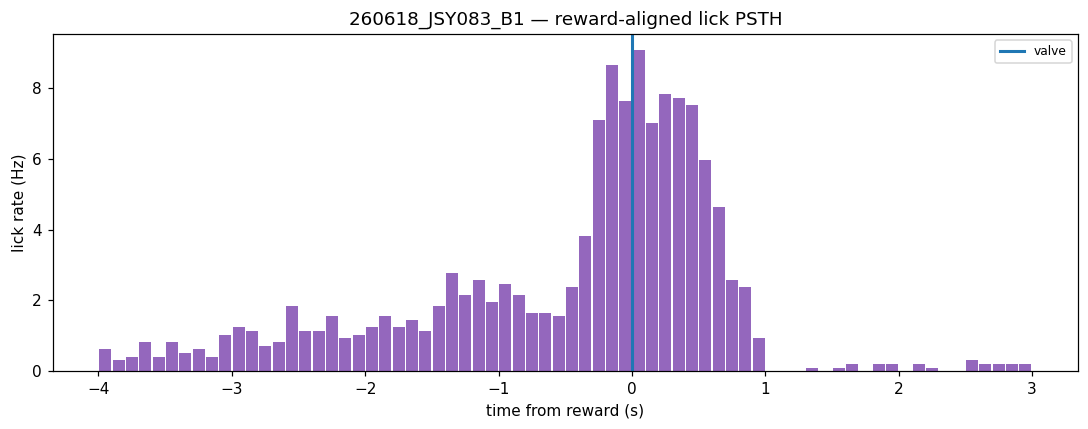

In [5]:
psth = reward_psth(licks_df, trial_df, model, window=PSTH_WINDOW, binw=PSTH_BINW)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(psth.t_from_reward_s, psth.rate_hz, PSTH_BINW * 0.9, color="tab:purple")
ax.axvline(0, color="tab:blue", lw=2, label="valve")
ax.set_xlabel("time from reward (s)"); ax.set_ylabel("lick rate (Hz)")
ax.set_title(f"{RECORDING} — reward-aligned lick PSTH"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Per-trial first (approach) lick

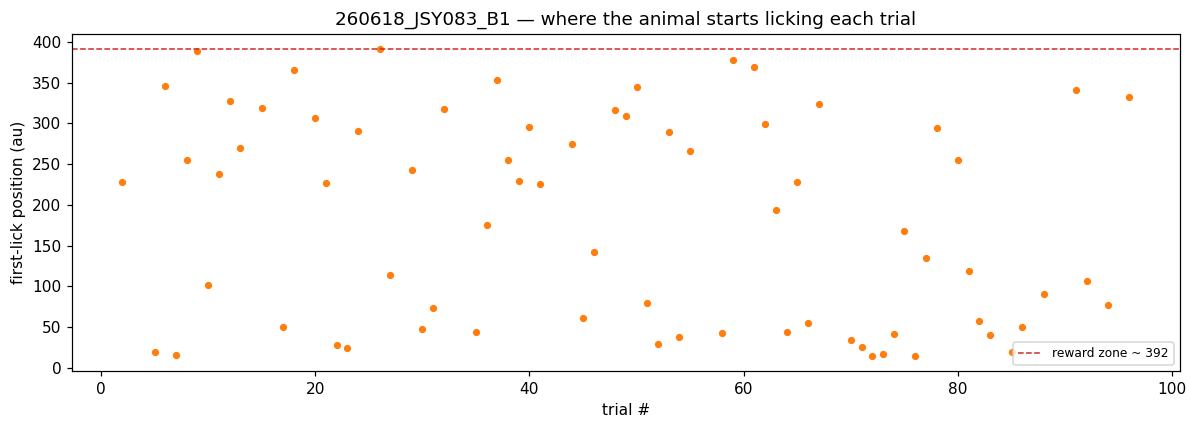

first-lick position: median 194 au   sd 127   (71/98 trials with an approach lick)


In [6]:
first_licks = first_approach_lick(licks_df, trial_df)

fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(first_licks.trial, first_licks.first_lick_pos_au, s=14, color="tab:orange")
ax.axhline(REWARD_ZONE_AU, color="tab:red", ls="--", lw=1, label=f"reward zone ~ {REWARD_ZONE_AU:.0f}")
ax.set_xlabel("trial #"); ax.set_ylabel("first-lick position (au)")
ax.set_title(f"{RECORDING} — where the animal starts licking each trial"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"first-lick position: median {np.nanmedian(first_licks.first_lick_pos_au):.0f} au   "
      f"sd {np.nanstd(first_licks.first_lick_pos_au):.0f}   "
      f"({first_licks.first_lick_pos_au.notna().sum()}/{len(first_licks)} trials with an approach lick)")

## 5. Within-session — early vs late trials

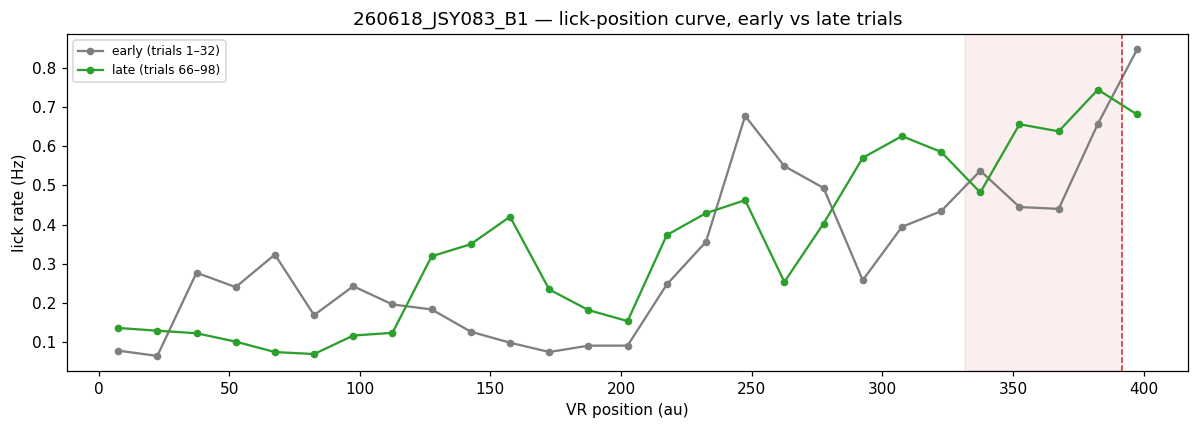

In [7]:
n = len(trial_df)
third = n // 3
early = trial_df.trial.to_numpy() <= trial_df.trial.iloc[third]
late  = trial_df.trial.to_numpy() >= trial_df.trial.iloc[-third]

c_early = lick_rate_vs_position(licks_df, vr, trial_df, binw=POS_BINW, trial_mask=early)
c_late  = lick_rate_vs_position(licks_df, vr, trial_df, binw=POS_BINW, trial_mask=late)

def _sm(y, k=3):
    return pd.Series(y).rolling(k, center=True, min_periods=1).mean().to_numpy()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(c_early.bin_center, _sm(c_early.rate_hz), "-o", ms=4, color="tab:gray", label=f"early (trials 1–{third})")
ax.plot(c_late.bin_center,  _sm(c_late.rate_hz),  "-o", ms=4, color="tab:green", label=f"late (trials {n-third}–{n})")
ax.axvline(REWARD_ZONE_AU, color="tab:red", ls="--", lw=1)
ax.axvspan(REWARD_ZONE_AU - ANTIC_SPAN, REWARD_ZONE_AU, color="tab:red", alpha=0.08)
ax.set_xlabel("VR position (au)"); ax.set_ylabel("lick rate (Hz)")
ax.set_title(f"{RECORDING} — lick-position curve, early vs late trials"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Speed control — is it deceleration?

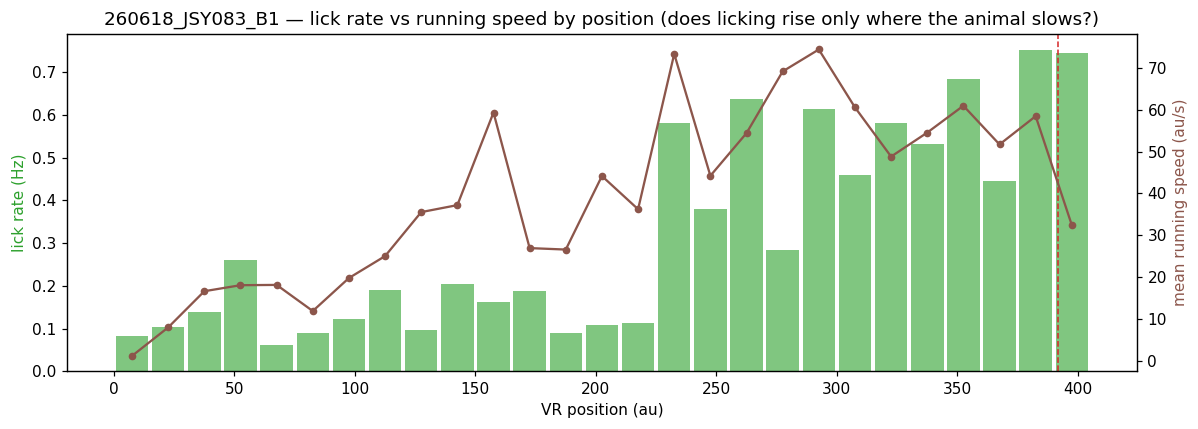

corr(lick rate, speed) across position bins: +0.68
  r <~ -0.5 : licking rises mainly where the animal slows (motor artifact)
  r >~  0   : licking is high while still running fast -> genuine anticipation
  peak running speed (deceleration starts) ~ 292 au   [anticipatory-onset metric is computed in cell 7]


In [8]:
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(curve.bin_center, curve.rate_hz, POS_BINW * 0.9, color="tab:green", alpha=0.6)
ax1.set_xlabel("VR position (au)"); ax1.set_ylabel("lick rate (Hz)", color="tab:green")
ax2 = ax1.twinx()
ax2.plot(speed.bin_center, speed.mean_speed_au_s, "-o", ms=4, color="tab:brown")
ax2.set_ylabel("mean running speed (au/s)", color="tab:brown")
ax1.axvline(REWARD_ZONE_AU, color="tab:red", ls="--", lw=1)
ax1.set_title(f"{RECORDING} — lick rate vs running speed by position "
              "(does licking rise only where the animal slows?)")
plt.tight_layout(); plt.show()

# correlation across bins
m = np.isfinite(curve.rate_hz) & np.isfinite(speed.mean_speed_au_s)
if m.sum() > 3:
    r = np.corrcoef(curve.rate_hz[m], speed.mean_speed_au_s[m])[0, 1]
    print(f"corr(lick rate, speed) across position bins: {r:+.2f}")
    print("  r <~ -0.5 : licking rises mainly where the animal slows (motor artifact)")
    print("  r >~  0   : licking is high while still running fast -> genuine anticipation")
decel_bin = float(speed.bin_center[np.nanargmax(speed.mean_speed_au_s.to_numpy())])
print(f"  peak running speed (deceleration starts) ~ {decel_bin:.0f} au   "
      f"[anticipatory-onset metric is computed in cell 7]")

## 7. Session metrics + save

In [9]:
metrics = session_metrics(curve, psth, licks_df, trial_df, REWARD_ZONE_AU,
                          first_licks, antic_span=ANTIC_SPAN,
                          neutral=NEUTRAL_ZONE, neutral_pad=NEUTRAL_PAD)
metrics = {"recording": RECORDING, **metrics}
mrow = pd.DataFrame([metrics])
mrow.T

,0
recording,260618_JSY083_B1
n_trials,97
n_licks,1572
n_approach_licks,438
n_consummatory_licks,1068
n_carryover_licks,66
rz_lick_rate_hz,0.603268
neutral_lick_rate_hz,0.216115
anticipatory_ratio,2.791414
anticipatory_onset_au,292.5


In [10]:
out_csv = os.path.join(RECORDING_FOLDER, f"{RECORDING}_lickmetrics.csv")
out_h5  = os.path.join(RECORDING_FOLDER, f"{RECORDING}_lickmetrics.h5")
mrow.to_csv(out_csv, index=False)

with h5py.File(out_h5, "w") as f:
    for name, dfc in [("curve", curve), ("curve_early", c_early), ("curve_late", c_late),
                      ("speed", speed), ("psth", psth), ("first_licks", first_licks)]:
        gg = f.create_group(name)
        for c in dfc.columns:
            gg.create_dataset(c, data=dfc[c].to_numpy(dtype=float))
    for k, v in metrics.items():
        if k != "recording":
            f.attrs[k] = v
    f.attrs["recording"] = RECORDING
    f.attrs["reward_zone_au"] = REWARD_ZONE_AU

print("wrote", out_csv)
print("wrote", out_h5)

wrote F:\dlc\test\260618_JSY083_B1_lickmetrics.csv
wrote F:\dlc\test\260618_JSY083_B1_lickmetrics.h5


---
**Next:** `4.SessionComparison.ipynb` — run 1–3 over every session of an animal
(config list), stack the metric rows into the **baseline learning trajectory**,
then **saline vs. trained baseline** and **DCZ 100 / 200 vs. saline & baseline**.